# Phase 7 — Residual Networks

The final piece: **stacking residual blocks into a deep network**.

Phase 5 showed the problem — as a plain network gets deeper, the signal degrades
on its way through the stack and training stalls. A **residual block** adds a
*skip connection* around a small block of layers:

$$\text{out} = x + \text{block}(x)$$

The `+ x` gives the signal (and the gradient) a clean, unobstructed path around
every block, so we can stack many of them and still train.

To show that the skip connection is what matters, this notebook runs a **fair,
single-variable comparison**. Both networks are *identical* — same width, same
36 layers, same `BatchNorm → ReLU → Linear` blocks. The **only** difference is
whether each block is wrapped in a skip connection:

| Network | Blocks | The one difference | What happens |
| --- | --- | --- | --- |
| **Plain deep** | `BatchNorm → ReLU → Linear` × 18 | no skip | degrades to near-chance |
| **Deep ResNet** | same blocks, each in `Residual(...)` | `+ x` skip | solves the task almost immediately |

BatchNorm sits in *both* networks, so it cannot be what separates them — it is
there to keep each block's inputs at a stable scale (a residual stream keeps
*adding* to itself, so without normalization it would grow until it overflows).

In [1]:
from pathlib import Path
from random import seed
from statistics import mean

import matplotlib.pyplot as plt

from babygrad.data import CSVDataset, DataLoader, split_train_val_test
from babygrad.metrics import Accuracy
from babygrad.nn.activations import ReLU, Softmax
from babygrad.nn.losses import CCE
from babygrad.nn.model import Model
from babygrad.nn.modules import BatchNorm, Linear, Residual, Sequential
from babygrad.nn.optimizers import SGD
from babygrad.observers import Tracer
from babygrad.tensor import Tensor
from babygrad.tracing import tracing
from babygrad.viz.attribution import attribute
from babygrad.viz.graph import GraphVisualizer
from babygrad.types import NodeKind

seed(0)  # deterministic split, shuffling, and weight init

# run from notebooks/ (Jupyter default) or the repo root
DATA = Path("../data/concentric_circles.csv")
if not DATA.exists():
    DATA = Path("data/concentric_circles.csv")

## The dataset — concentric circles

Two classes: an inner disk (`inner`) and an outer ring (`outer`) separated by an
empty margin (5000 balanced
rows, two inputs `x1, x2`, one string label). Generator:
`python data/generate_concentric_circles.py`.

In [2]:
dataset = CSVDataset(DATA, target_col_idx=2)

# The file holds 5000 rows. Training 36-layer nets in pure Python is slow, so we
# train on a 1250-row slice — still plenty for this clean signal.
full_row_count = len(dataset)
dataset.data = dataset.data[:1250]
train, val, test = split_train_val_test(dataset, one_hot=True)

print(f"{full_row_count} rows on disk, using {len(dataset)}   "
      f"train={len(train)} val={len(val)} test={len(test)}")
print(f"n_features {train.n_features}   n_targets {train.n_targets}")
print(f"one-hot    {train.one_hot_mapping}")

5000 rows on disk, using 1250   train=1000 val=125 test=125
n_features 2   n_targets 2
one-hot    {'inner': [1, 0], 'outer': [0, 1]}


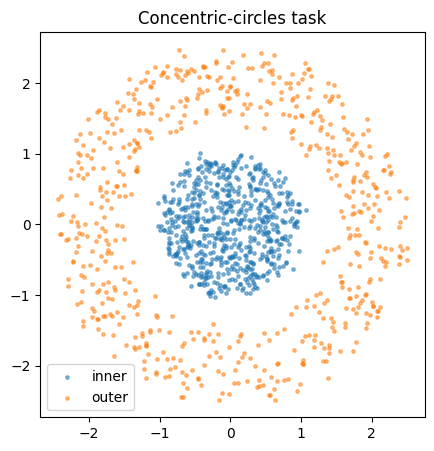

In [3]:
# Plot the raw task. No straight line can separate the disk from the ring —
# the boundary is a circle, which the network must build from x1, x2.
inner = [(s.features[0], s.features[1]) for s in dataset.data if s.target[0] == "inner"]
outer = [(s.features[0], s.features[1]) for s in dataset.data if s.target[0] == "outer"]

plt.figure(figsize=(5, 5))
plt.scatter(*zip(*inner), s=6, alpha=0.5, label="inner")
plt.scatter(*zip(*outer), s=6, alpha=0.5, label="outer")
plt.gca().set_aspect("equal")
plt.title("Concentric-circles task")
plt.legend()
plt.show()

## Two networks, one difference

`build(use_skip)` assembles the network from a shared `block_body`
(`BatchNorm → ReLU → Linear`, twice). With `use_skip=False` the blocks are
stacked directly; with `use_skip=True` each block is wrapped in `Residual`,
which returns `x + block(x)`. Everything else is identical, so any difference in
training comes purely from the skip.

`train_model` is the standard loop from Phase 4/6: minibatch SGD, categorical
cross-entropy, per-epoch validation. `model.forward` runs in *training* mode
(BatchNorm uses batch statistics); `model.eval` runs in *inference* mode
(BatchNorm uses its running statistics).

In [4]:
WIDTH = 16      # hidden width, shared by both networks
BLOCKS = 18     # 18 blocks * 2 Linears = 36 hidden layers, shared by both


def block_body():
    return [
        BatchNorm(WIDTH), ReLU(), Linear(WIDTH, WIDTH),
        BatchNorm(WIDTH), ReLU(), Linear(WIDTH, WIDTH),
    ]


def build(use_skip):
    layers = [Linear(train.n_features, WIDTH)]              # stem: 2 -> WIDTH
    for _ in range(BLOCKS):
        block = Sequential(block_body())
        layers.append(Residual(block) if use_skip else block)  # <-- the only difference
    layers += [Linear(WIDTH, train.n_targets), Softmax()]  # head: WIDTH -> 2 classes
    return Sequential(layers)


def train_model(net, epochs=5, batch_size=64, lr=0.1):
    model = Model(net)
    optimizer = SGD(net.parameters())
    optimizer.lr = lr
    criterion = CCE()
    val_x, val_y = DataLoader(val).full_batch()

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    for _ in range(epochs):
        batch_losses = []
        for x, y in DataLoader(train, batch_size):
            optimizer.zero_grad()
            loss = criterion.forward(y, model.forward(x))
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.data[0])

        val_pred = model.eval(val_x)
        history["train_loss"].append(mean(batch_losses))
        history["val_loss"].append(criterion.forward(val_y, val_pred).data[0])
        history["val_acc"].append(Accuracy().compute(val_y, val_pred))

    return model, criterion, history

### The plain deep network (no skip)

36 layers of `BatchNorm → ReLU → Linear`, stacked directly. Watch its accuracy
sit near chance — the signal cannot make it cleanly through 18 blocks and back.

> Pure-Python training: the two cells below take roughly two minutes each.

In [5]:
plain_net = build(use_skip=False)
plain_model, plain_criterion, plain_history = train_model(plain_net)
print(f"plain  final val_loss {plain_history['val_loss'][-1]:.4f}"
      f"   val_acc {plain_history['val_acc'][-1]:.3f}")

plain  final val_loss 0.6009   val_acc 0.456


### The deep ResNet (skip)

The *same* 36 layers — but now every block is wrapped in `Residual`, adding the
`+ x` skip. Nothing else changed.

In [6]:
resnet = build(use_skip=True)
resnet_model, resnet_criterion, resnet_history = train_model(resnet)
print(f"resnet final val_loss {resnet_history['val_loss'][-1]:.4f}"
      f"   val_acc {resnet_history['val_acc'][-1]:.3f}")

resnet final val_loss 0.0172   val_acc 0.992


## The payoff

Identical networks — same width, same 36 layers, same BatchNorm, same ReLU, same
optimizer. The single difference is the `+ x` skip, and that is the difference
between a network that learns the ring and one that never leaves chance.

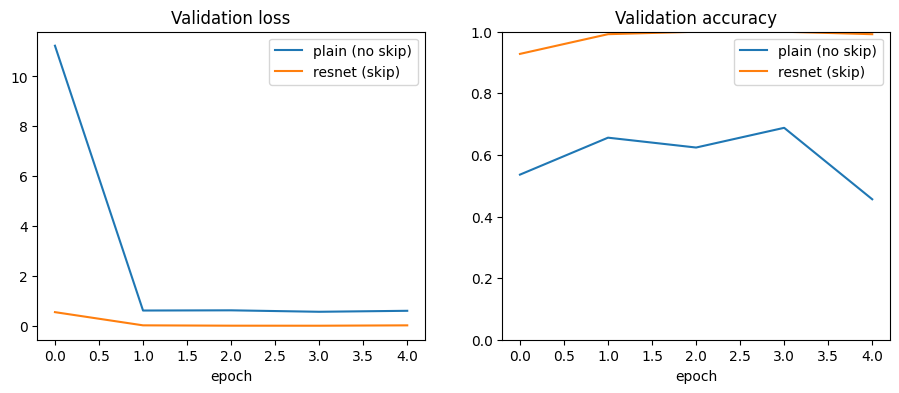

In [7]:
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(11, 4))

ax_loss.plot(plain_history["val_loss"], label="plain (no skip)")
ax_loss.plot(resnet_history["val_loss"], label="resnet (skip)")
ax_loss.set_title("Validation loss")
ax_loss.set_xlabel("epoch")
ax_loss.legend()

ax_acc.plot(plain_history["val_acc"], label="plain (no skip)")
ax_acc.plot(resnet_history["val_acc"], label="resnet (skip)")
ax_acc.set_title("Validation accuracy")
ax_acc.set_xlabel("epoch")
ax_acc.set_ylim(0, 1)
ax_acc.legend()

plt.show()

## What the ResNet learned

Sweep a grid across the input plane, ask the trained ResNet to classify every
point, and shade the two regions. The learned boundary should hug the ring.

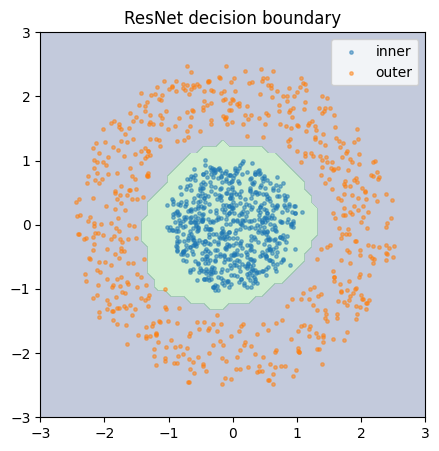

In [8]:
RESOLUTION, LOW, HIGH = 60, -3.0, 3.0
axis = [LOW + (HIGH - LOW) * i / (RESOLUTION - 1) for i in range(RESOLUTION)]

grid_points = []
for gy in axis:
    for gx in axis:
        grid_points.extend([gx, gy])

grid = Tensor(grid_points, shape=(RESOLUTION * RESOLUTION, 2), kind=NodeKind.INPUT)
probs = resnet_model.eval(grid).data

# The one-hot column order depends on which label appears first in training, so
# look up the "inner" column instead of assuming it. region = 1 where the net
# predicts inner, 0 where it predicts outer.
inner_col = train.one_hot_mapping["inner"].index(1)
outer_col = 1 - inner_col
prediction = [
    1 if probs[2 * k + inner_col] >= probs[2 * k + outer_col] else 0
    for k in range(RESOLUTION * RESOLUTION)
]
region = [prediction[r * RESOLUTION:(r + 1) * RESOLUTION] for r in range(RESOLUTION)]

plt.figure(figsize=(5, 5))
plt.contourf(axis, axis, region, levels=1, alpha=0.3)
plt.scatter(*zip(*inner[:800]), s=6, alpha=0.5, label="inner")
plt.scatter(*zip(*outer[:800]), s=6, alpha=0.5, label="outer")
plt.gca().set_aspect("equal")
plt.title("ResNet decision boundary")
plt.legend()
plt.show()

## The architecture graph

The same visualizer from Phase 5, now showing a residual network. The full
18-block model would be a very tall graph, so we draw a **2-block schematic**
with the same structure. Look for the skip edges bypassing each block — that
extra path around `block(x)` is the whole idea.

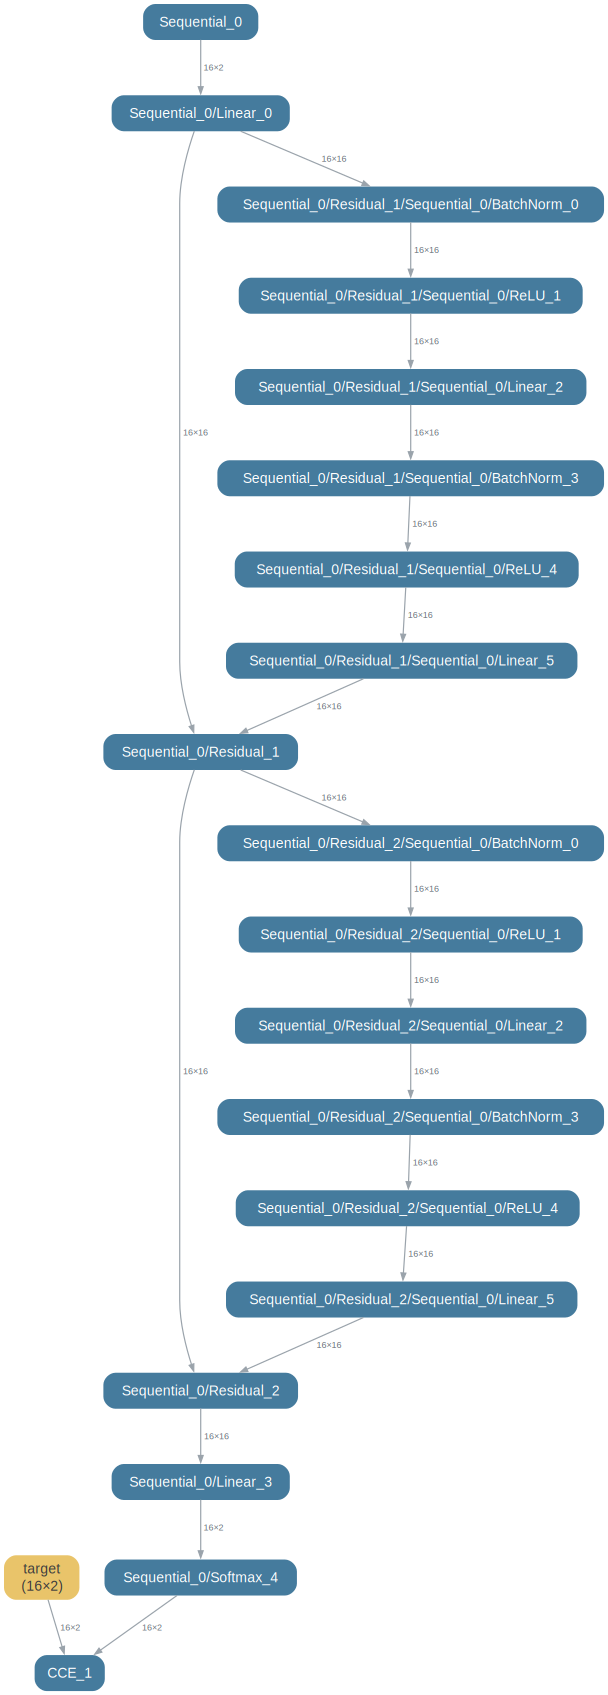

In [9]:
schematic = Sequential([
    Linear(train.n_features, WIDTH),
    Residual(Sequential(block_body())),
    Residual(Sequential(block_body())),
    Linear(WIDTH, train.n_targets),
    Softmax(),
])
schematic_model = Model(schematic)
schematic_criterion = CCE()

demo_x, demo_y = DataLoader(val, batch_size=16).full_batch()
# Trace the forward pass so the graph knows which scope each node belongs to.
tracer = Tracer()
with tracing(tracer):
    loss = schematic_criterion(demo_y, schematic_model.forward(demo_x))
graph = GraphVisualizer(loss, attribute(tracer.records))
graph.draw_architecture()

## Held-out test set

In [10]:
test_x, test_y = DataLoader(test).full_batch()
resnet_test = resnet_model.eval(test_x)
plain_test = plain_model.eval(test_x)
print(f"resnet test acc {Accuracy().compute(test_y, resnet_test):.3f}")
print(f"plain  test acc {Accuracy().compute(test_y, plain_test):.3f}")

resnet test acc 1.000
plain  test acc 0.472


## Takeaways

- The comparison is **fair**: the two networks differ by exactly one thing, the
  `out = x + block(x)` skip. Same width, depth, activation, normalization, and
  optimizer. So the gap is caused by the skip and nothing else.
- The **skip connection** gives the signal and its gradient a direct route
  through every block, so depth stops fighting training. **BatchNorm** rides
  along (in both networks) to keep the residual stream at a stable scale.
- With that, **stacking residual blocks** turns depth into an asset: the ResNet
  learns the circular boundary the equally-deep plain network could not.
- Nothing here is special-cased — it is the same `Sequential`, `Linear`,
  `BatchNorm`, SGD, and autograd built over the previous phases, composed one
  step further. That was the whole point of babygrad.